# 04 · Interpretation: what drives the predictions?

Three complementary views on the fitted models:

1. **statistical inference** on the unpenalised logistic regression (statsmodels GLM: standard errors, p-values, deviance residuals, influence);
2. **XGBoost native importances** (gain vs split count) and their change under SMOTE-NC;
3. **SHAP values** on the test split and **out-of-fold permutation importance** for the random forest.

The models are refitted here with the same builders as notebook 03.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coffee_quality import config as C
from coffee_quality import data, eda, plotting as P

P.set_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
from coffee_quality import evaluation as E, interpret as I
from coffee_quality.models import boosting, forest, logistic

df = data.load_clean()
X, y = data.make_model_matrix(df)
X_train, X_test, y_train, y_test = data.stratified_split(X, y)

spw = boosting.imbalance_ratio(y_train)
n_trees, _ = boosting.freeze_n_estimators(X_train, y_train)
xgb = E.evaluate("XGBoost", boosting.build_xgboost(n_trees, spw), X_train, y_train, X_test, y_test, n_boot=0)
xgb_fe = E.evaluate("XGBoost + FE", boosting.build_xgboost(n_trees, spw, engineer=True), X_train, y_train, X_test, y_test, n_boot=0)
smote = E.evaluate("XGBoost + SMOTE-NC", boosting.build_smotenc_xgboost(n_trees), X_train, y_train, X_test, y_test, n_boot=0)
rf = E.evaluate("Random forest", forest.build_random_forest(), X_train, y_train, X_test, y_test, n_boot=0)
print("fitted")

fitted


## 1. Logistic regression as a GLM

In [2]:
glm, design = logistic.fit_glm(X_train, y_train)
glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Excellent   No. Observations:                  992
Model:                            GLM   Df Residuals:                      967
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -476.07
Date:                Fri, 18 Sep 2026   Deviance:                       952.14
Time:                        11:25:50   Pearson chi2:                     964.
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3472
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -1.4234      0.249     -5.714      0.000      -1.912      -0.935
Moisture                           -0.3029      0.101     -3.005      0.003      -0.500      -0.105
Category.One.Defects                0.1030      0.138      0.745      0.456      -0.168       0.374
Category.Two.Defects               -0.6104      0.144     -4.225      0.000      -0.894      -0.327
altitude_mean_meters                0.7637      0.118      6.448      0.000       0.532       0.996
Moisture_missing                    0.3311      0.087      3.811      0.000       0.161       0.501
MacroArea_Africa                    1.0924      0.285      3.838      0.000       0.535       1.650
MacroArea_Mainland Asia            -0.7688      0.470     -1.636      0.102      -1.690       0.152
MacroArea_Maritime Asia/Pacific     0.9960      0.370      2.690      0.007       0.270       1.722
MacroArea_South America            -0.6045      0.242     -2.493      0.013      -1.080      -0.129
Color_Unknown                       0.3164      0.286      1.107      0.268      -0.244       0.876
Color_blue-green                    0.5391      0.227      2.375      0.018       0.094       0.984
Processing.Method_Honey             1.0474      1.013      1.034      0.301      -0.938       3.033
Processing.Method_Natural           1.4821      0.230      6.439      0.000       1.031       1.933
Processing.Method_Semi-washed       1.6759      0.421      3.979      0.000       0.850       2.501
Processing.Method_Unknown           0.4503      0.359      1.254      0.210      -0.254       1.154
Variety_Bourbon                     0.1758      0.291      0.604      0.546      -0.395       0.746
Variety_Catuai                     -0.0886      0.416     -0.213      0.831      -0.904       0.727
Variety_Hawaiian Kona              -0.1034      0.563     -0.184      0.854      -1.207       1.000
Variety_Mundo Novo                -21.9619   1.86e+04     -0.001      0.999   -3.66e+04    3.65e+04
Variety_Other                       0.1789      0.338      0.529      0.597      -0.484       0.842
Variety_Typica                     -1.4337      0.427     -3.359      0.001      -2.270      -0.597
Variety_Unknown                     0.5685      0.338      1.682      0.092      -0.094       1.231
Variety_Yellow Bourbon            -23.1804   2.35e+04     -0.001      0.999   -4.61e+04     4.6e+04
Variety_Rare                        0.4481      0.342      1.312      0.190      -0.221       1.118
===================================================================================================
"""

Standardised coefficients read as log-odds per standard deviation (numeric) or versus the reference level (Caturra / washed / green / Central-North America for the dummies). Significant at the 5% level: altitude (+0.76 per SD), category-two defects (−0.61), moisture (−0.30), the moisture-missing flag (+0.33), natural and semi-washed processing (+1.5 / +1.7 vs washed), African and Maritime-Asia/Pacific origin (+1.1 / +1.0), South-American origin (−0.60) and the Typica variety (−1.4). Most other variety dummies are not — they are too sparse — and Mundo Novo / Yellow Bourbon (no excellent lot among ~20) show the quasi-separation signature: a huge negative coefficient with an even larger standard error.

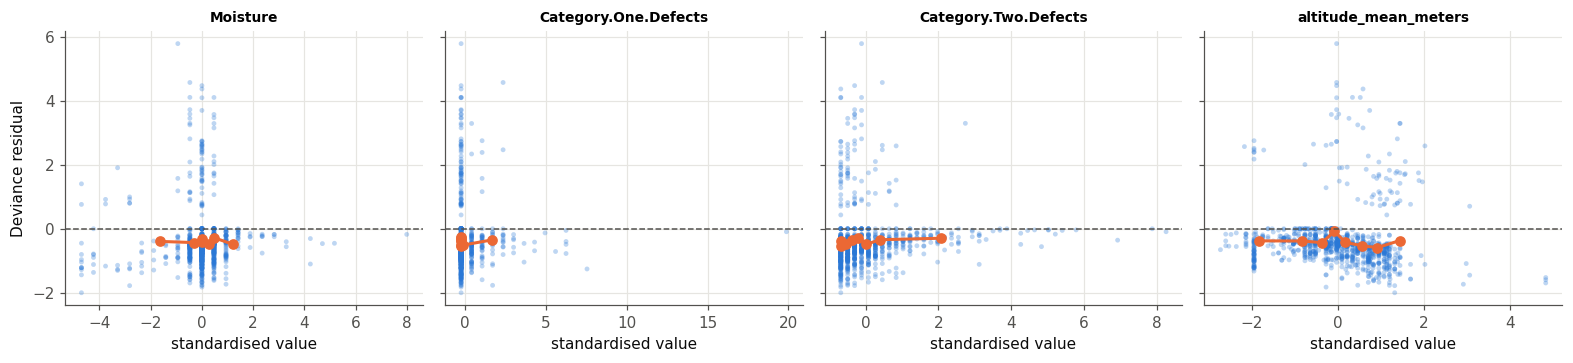

In [3]:
P.plot_glm_residuals(glm, design, C.NUMERIC_FEATURES);

Deviance residuals against each standardised numeric predictor, with the binned mean in orange. The mean curve stays flat around zero: the logit is approximately linear in these variables and no transformation is called for. The vertical stripes of large positive residuals are excellent lots that look perfectly ordinary on every numeric variable — the model has no way to reach them.

,Moisture,Category.One.Defects,Category.Two.Defects,altitude_mean_meters,Country.of.Origin,Region,Variety,Processing.Method,Color,Excellent
80,0.10,0,3,NaN,Ethiopia,yirgacheffe,Typica,Unknown,Unknown,1
68,0.10,0,18,1900.0,Ethiopia,oromia,Unknown,Washed,green,1
18,0.10,0,0,1450.0,China,yunnan,Catimor,Washed,green,1
97,0.09,0,3,1300.0,Mexico,veracruz,Typica,Washed,green,1
58,0.10,4,6,NaN,Peru,cajamarca,Unknown,Washed,green,1


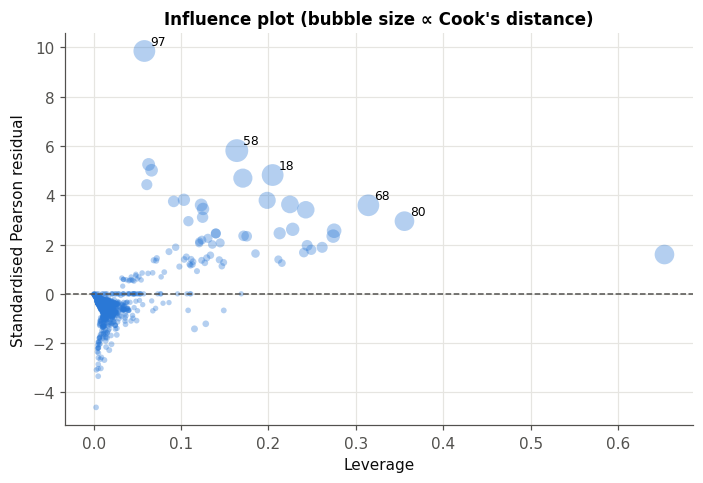

In [4]:
fig, influential = P.plot_influence(glm)
X_train.loc[influential].assign(Excellent=y_train.loc[influential])

The most influential points (largest Cook's distance) are excellent lots with average agronomic profiles, not data errors. Removing them would only make the model more confident about a pattern that does not exist, so they stay.

## 2. XGBoost: gain vs split count

,feature,gain,weight
0,MacroArea_Africa,34.81,231.0
1,Processing.Method_Washed,19.71,315.0
2,Moisture_missing,13.70,230.0
3,Color_green,13.19,305.0
4,Variety_Typica,12.86,266.0
5,MacroArea_Maritime Asia/Pacific,11.25,227.0
6,Color_blue-green,10.18,262.0
7,altitude_mean_meters,9.65,2927.0
8,Category.Two.Defects,9.14,1206.0
9,MacroArea_South America,9.07,312.0


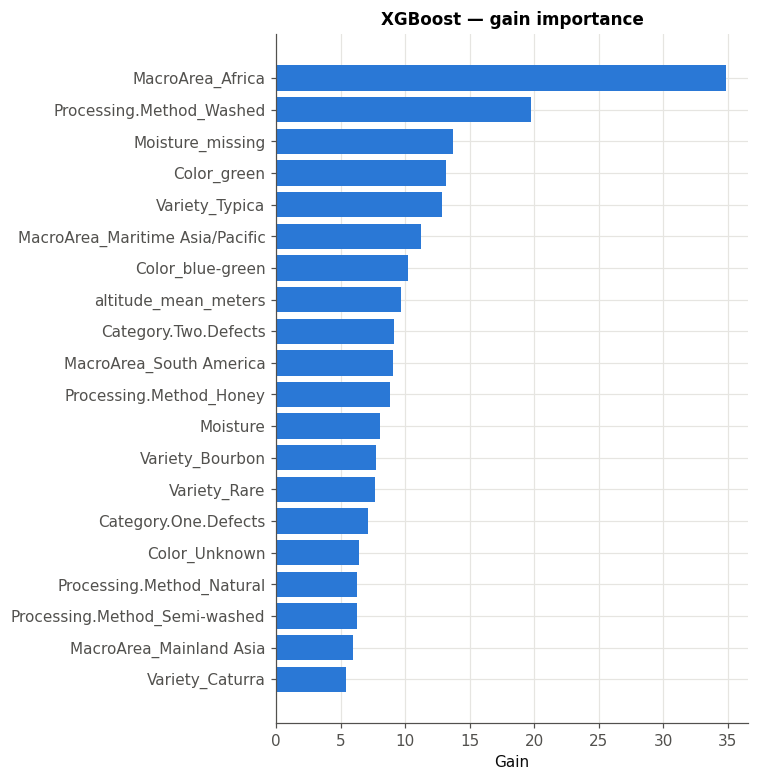

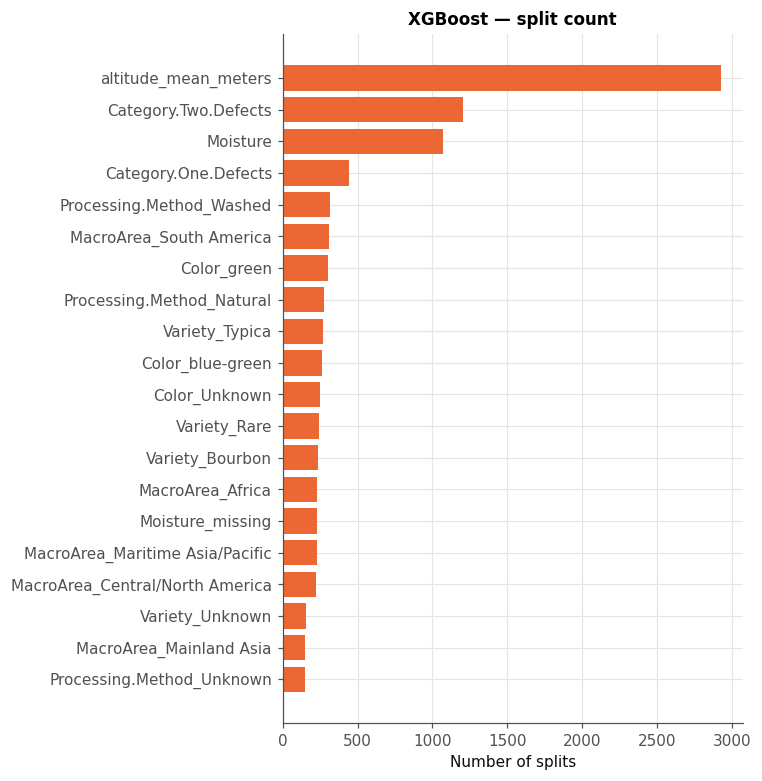

In [5]:
gain = I.xgb_importance(xgb.estimator)
P.plot_importance(gain, "gain", "Gain", "XGBoost — gain importance");
P.plot_importance(gain.sort_values("weight", ascending=False), "weight", "Number of splits", "XGBoost — split count", color=P.SERIES[1]);
gain.head(10).round(2)

The two native importances disagree, and the disagreement is informative. *Gain* is dominated by categorical dummies (African origin, washed processing, the missing-moisture flag, the Typica variety): each split on them purifies a node a lot, once. *Split count* is dominated by the continuous variables (altitude, category-two defects): the trees keep slicing them into ever-finer intervals — a symptom of the model chasing individual lots.

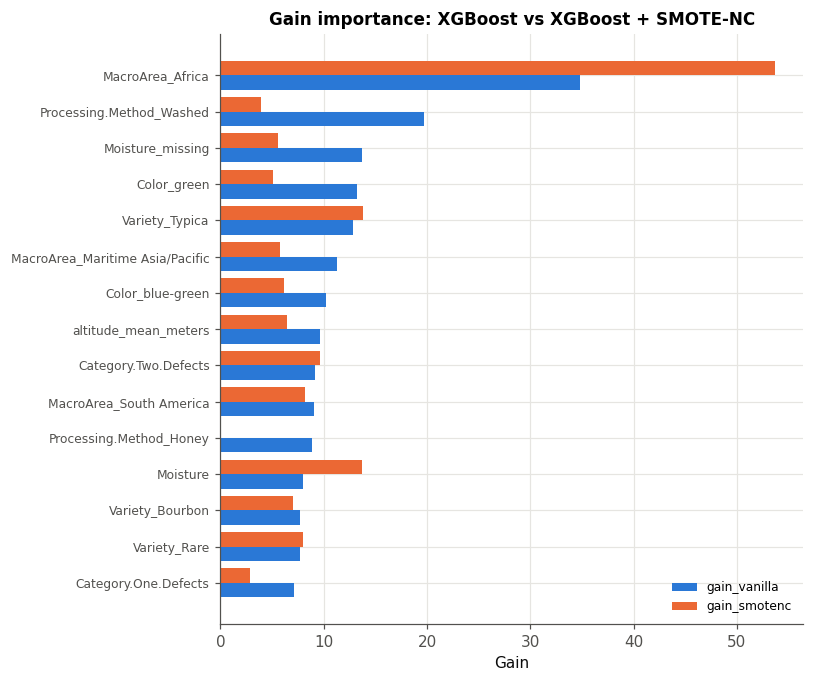

In [6]:
gain_s = I.xgb_importance(smote.estimator).rename(columns={"gain": "gain_smotenc"})
comp = gain.merge(gain_s[["feature", "gain_smotenc"]], on="feature", how="outer").fillna(0).rename(columns={"gain": "gain_vanilla"}).sort_values("gain_vanilla", ascending=False)
P.plot_importance_comparison(comp, ["gain_vanilla", "gain_smotenc"], "Gain importance: XGBoost vs XGBoost + SMOTE-NC");

Training on SMOTE-NC-balanced folds redistributes the gain: origin gains weight, while the washed-process and missing-moisture dummies — the "lab signature" variables — lose most of theirs. Oversampling makes the model rely on more plausible agronomic signals, but as notebook 03 shows it does not make it more accurate.

## 3. SHAP values

,feature,mean_abs_shap
0,altitude_mean_meters,1.253
1,Category.Two.Defects,0.759
2,Processing.Method_Washed,0.505
3,Moisture,0.498
4,Variety_Typica,0.379
5,MacroArea_Africa,0.304
6,MacroArea_Central/North America,0.301
7,Color_green,0.280
8,MacroArea_Maritime Asia/Pacific,0.256
9,MacroArea_South America,0.208


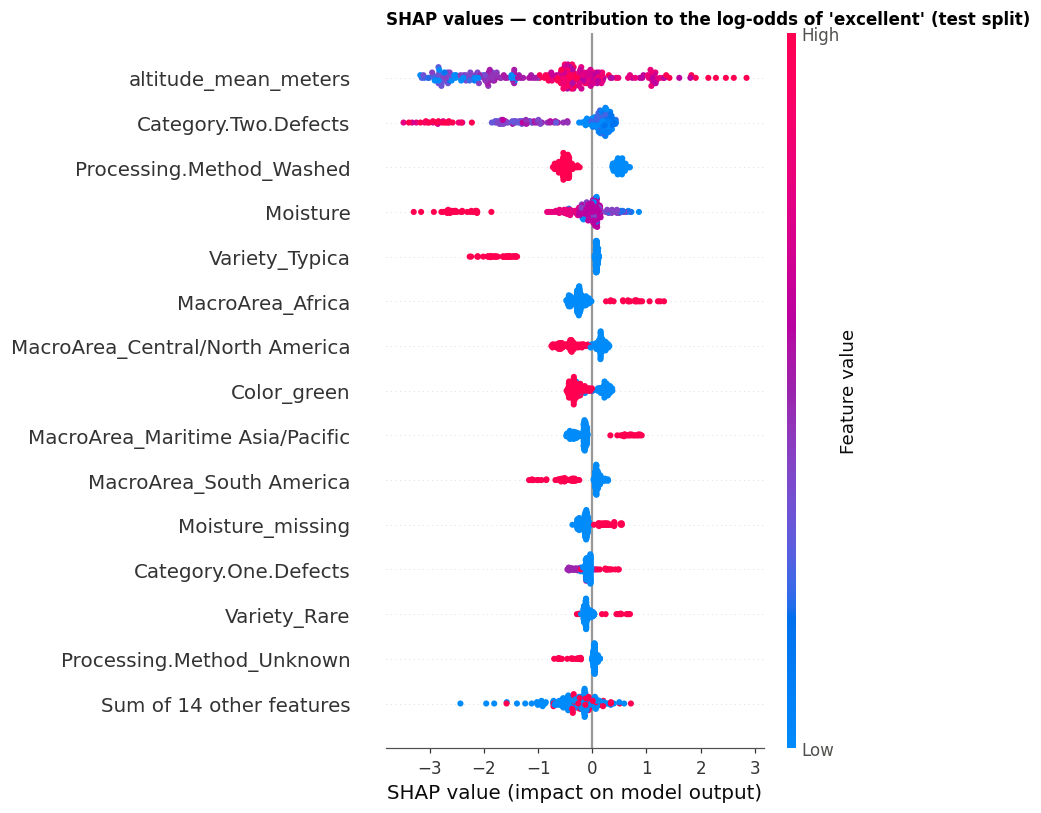

In [7]:
values, matrix = I.shap_values(xgb.estimator, X_test)
P.plot_shap_beeswarm(values);
I.shap_summary_table(values).head(10).round(3)

SHAP adds *direction* to importance. Reading the beeswarm:

* **altitude** is the top contributor and monotone: high values push toward *excellent*, low values away;
* **category-two defects** and **moisture** work in the opposite direction — many defects or high moisture are almost disqualifying;
* **washed processing** lowers the log-odds, natural/unknown processing raises them (the latter largely because unknown metadata co-occurs with Ethiopian lots);
* the **Typica** variety and **South-American** origin lower the odds; **African** and **Maritime Asia/Pacific** origins raise them.

The same picture for the feature-engineered model — the `log(altitude/moisture)` interaction takes over part of altitude's role:

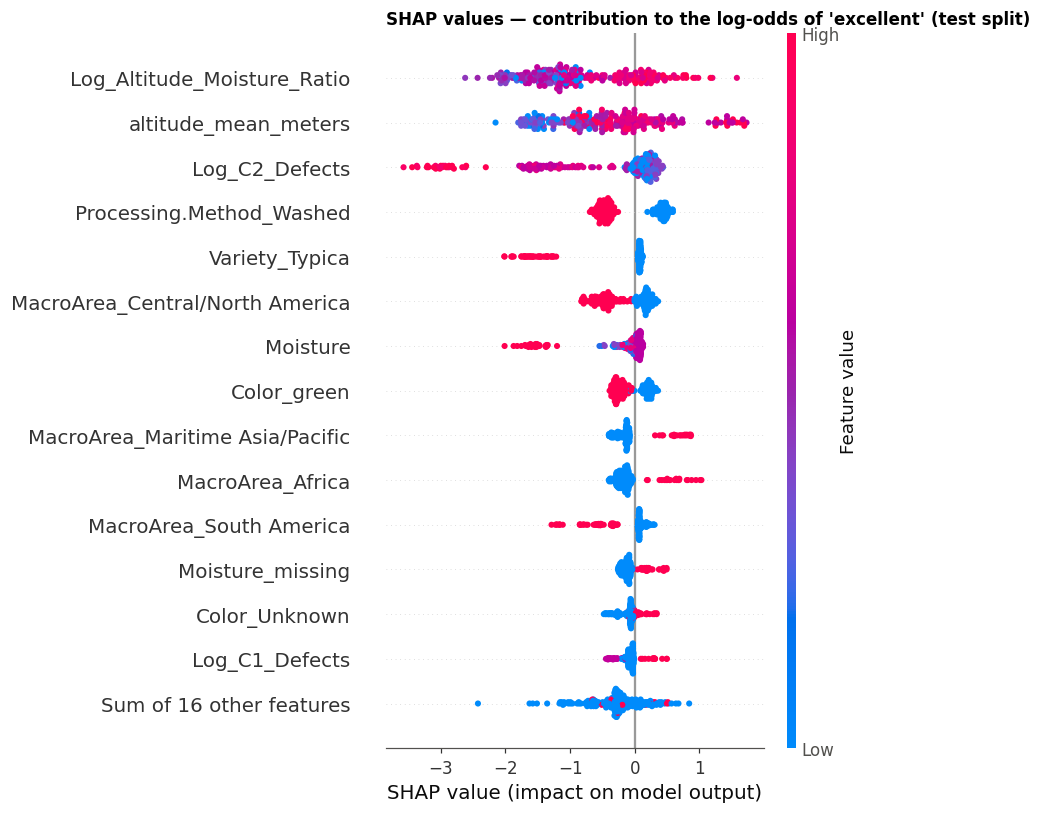

In [8]:
values_fe, _ = I.shap_values(xgb_fe.estimator, X_test)
P.plot_shap_beeswarm(values_fe);

## 4. Random forest: out-of-fold permutation importance

raw_feature
altitude_mean_meters    0.152
MacroArea               0.078
Processing.Method       0.073
Moisture                0.035
Category.Two.Defects    0.024
Color                   0.018
Moisture_missing        0.013
Variety                 0.011
Category.One.Defects   -0.002
Name: importance_mean, dtype: float64

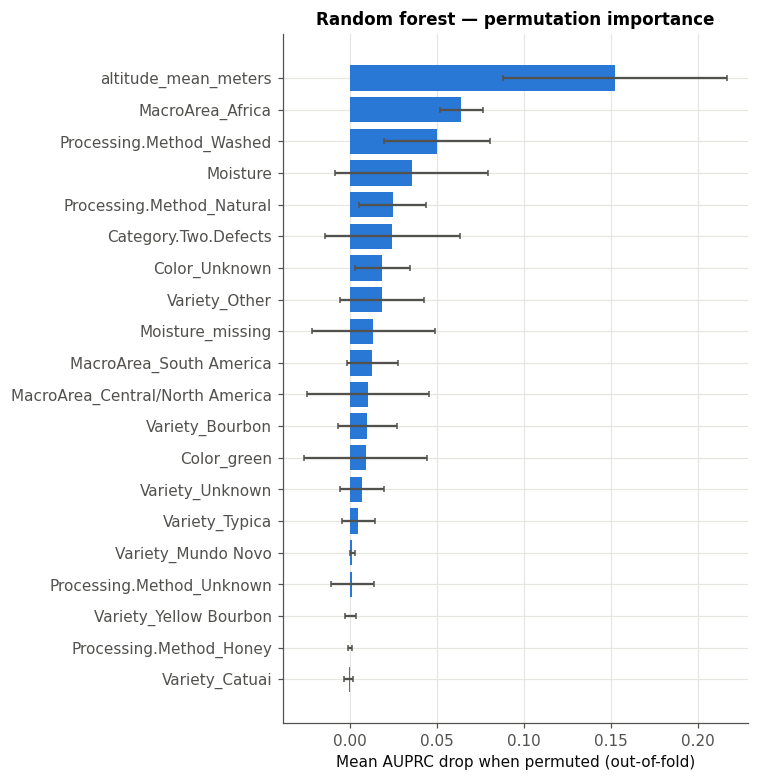

In [9]:
perm = I.cv_permutation_importance(rf.estimator.best_estimator_, X_train, y_train, n_repeats=10)
P.plot_importance(perm, "importance_mean", "Mean AUPRC drop when permuted (out-of-fold)", "Random forest — permutation importance", error="importance_std");
perm.groupby("raw_feature")["importance_mean"].sum().sort_values(ascending=False).round(3)

Permutation importance is computed on the held-out fold of each CV split (never on the test split, as in the original notebook) and measured as the drop in AUPRC. Altitude alone accounts for a 0.15 drop; origin, processing method, moisture and category-two defects follow; the variety and colour dummies are individually negligible and unstable across folds (large error bars).

## Take-away

All three views converge: **altitude, secondary defects, moisture, processing method and macro-origin** carry whatever signal exists, and they agree in direction with the agronomic literature (higher, cleaner, drier lots from East Africa score better). What the models lack is not the right variables but *resolution*: two lots with the same altitude, origin and defects can still differ by ten cup points because of soil, micro-climate, harvest timing and post-harvest handling that the dataset does not record.